In [2]:
import zarr

zarr_path = '/scratch/cimes/maximek/INMOS/processed_data/MOM6_CobaltDG_Clim/bgc_data.zarr'

print("Recreating consolidated metadata...")
zarr.consolidate_metadata(zarr_path)
print("Done! Metadata recreated.")

Recreating consolidated metadata...
Done! Metadata recreated.


In [13]:
import zarr
import numpy as np

store = zarr.open('/scratch/cimes/maximek/INMOS/processed_data/MOM6_CobaltDG_Clim/bgc_data.zarr', mode='r')
psi_data = store['psi_0']

# Check every 10th timestep
print("Checking every 10th timestep...")
for t in range(0, 3650, 10):
    sample = psi_data[t, 0, 0]  # Just check a single point
    if sample != 0 or np.isnan(sample):
        print(f"t={t}: FILLED")
    else:
        print(f"t={t}: EMPTY - stopped here!")
        print(f"\nEstimated progress: ~{t}/3650 = {100*t/3650:.1f}%")
        break

Checking every 10th timestep...
t=0: EMPTY - stopped here!

Estimated progress: ~0/3650 = 0.0%


In [8]:
import xarray as xr
import numpy as np
from scipy.sparse import diags, lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve
from tqdm import tqdm


def build_laplacian_neumann(ny, nx, dx, dy):
    """
    Build 2D Laplacian with Neumann BC (∂/∂n = 0) on all boundaries.
    For velocity potential φ.
    """
    N = nx * ny
    L = lil_matrix((N, N))
    
    dx2_inv = 1.0 / (dx * dx)
    dy2_inv = 1.0 / (dy * dy)
    
    for i in range(ny):
        for j in range(nx):
            idx = i * nx + j
            
            # Accumulate center coefficient as we add neighbors
            center = 0.0
            
            # Left (j-1)
            if j > 0:
                L[idx, idx - 1] = dx2_inv
                center -= dx2_inv
            
            # Right (j+1)
            if j < nx - 1:
                L[idx, idx + 1] = dx2_inv
                center -= dx2_inv
            
            # Bottom (i-1)
            if i > 0:
                L[idx, idx - nx] = dy2_inv
                center -= dy2_inv
            
            # Top (i+1)
            if i < ny - 1:
                L[idx, idx + nx] = dy2_inv
                center -= dy2_inv
            
            # Set center coefficient
            L[idx, idx] = center
    
    return L.tocsr()

def build_laplacian_dirichlet(ny, nx, dx, dy):
    """
    Build 2D Laplacian with Dirichlet BC (ψ = 0) on all boundaries.
    For streamfunction ψ.
    """
    N = nx * ny
    L = lil_matrix((N, N))
    
    dx2_inv = 1.0 / (dx * dx)
    dy2_inv = 1.0 / (dy * dy)
    
    for i in range(ny):
        for j in range(nx):
            idx = i * nx + j
            
            # Boundary points: enforce ψ = 0
            if i == 0 or i == ny-1 or j == 0 or j == nx-1:
                L[idx, idx] = 1.0
            else:
                # Interior: standard 5-point stencil
                L[idx, idx] = -2*dx2_inv - 2*dy2_inv
                L[idx, idx - 1] = dx2_inv      # left
                L[idx, idx + 1] = dx2_inv      # right
                L[idx, idx - nx] = dy2_inv     # bottom
                L[idx, idx + nx] = dy2_inv     # top
    
    return L.tocsr()

def velocity_to_helmholtz_walls(u, v, dx, dy):
    """
    Helmholtz decomposition with wall boundary conditions.
    
    Returns:
    - psi: streamfunction (ψ = 0 on walls)
    - phi: velocity potential (∂φ/∂n = 0 on walls)  
    - div: divergence
    - vort: vorticity
    """
    ny, nx = u.shape
    
    # Compute divergence and vorticity using central differences
    div = np.zeros_like(u)
    vort = np.zeros_like(u)
    
    # Interior points
    div[1:-1, 1:-1] = (
        (u[1:-1, 2:] - u[1:-1, :-2]) / (2 * dx) +
        (v[2:, 1:-1] - v[:-2, 1:-1]) / (2 * dy)
    )
    vort[1:-1, 1:-1] = (
        (v[1:-1, 2:] - v[1:-1, :-2]) / (2 * dx) -
        (u[2:, 1:-1] - u[:-2, 1:-1]) / (2 * dy)
    )
    
    # Boundaries (one-sided differences)
    # Left (j=0)
    div[:, 0] = (u[:, 1] - u[:, 0]) / dx + np.gradient(v[:, 0], dy, axis=0)
    vort[:, 0] = (v[:, 1] - v[:, 0]) / dx - np.gradient(u[:, 0], dy, axis=0)
    
    # Right (j=-1)
    div[:, -1] = (u[:, -1] - u[:, -2]) / dx + np.gradient(v[:, -1], dy, axis=0)
    vort[:, -1] = (v[:, -1] - v[:, -2]) / dx - np.gradient(u[:, -1], dy, axis=0)
    
    # Bottom (i=0)
    div[0, :] = np.gradient(u[0, :], dx, axis=0) + (v[1, :] - v[0, :]) / dy
    vort[0, :] = np.gradient(v[0, :], dx, axis=0) - (u[1, :] - u[0, :]) / dy
    
    # Top (i=-1)
    div[-1, :] = np.gradient(u[-1, :], dx, axis=0) + (v[-1, :] - v[-2, :]) / dy
    vort[-1, :] = np.gradient(v[-1, :], dx, axis=0) - (u[-1, :] - u[-2, :]) / dy
    
    # Build Laplacian matrices (only once per grid size - could cache these!)
    L_neumann = build_laplacian_neumann(ny, nx, dx, dy)
    L_dirichlet = build_laplacian_dirichlet(ny, nx, dx, dy)
    
    # Prepare RHS for Dirichlet BC
    vort_rhs = vort.ravel().copy()
    for i in range(ny):
        for j in range(nx):
            if i == 0 or i == ny-1 or j == 0 or j == nx-1:
                idx = i * nx + j
                vort_rhs[idx] = 0.0  # ψ = 0 on boundary
    
    # Solve Poisson equations
    psi = spsolve(L_dirichlet, vort_rhs).reshape(ny, nx)
    phi = spsolve(L_neumann, div.ravel()).reshape(ny, nx)
    
    # Remove mean from phi (gauge freedom)
    phi -= phi.mean()
    
    return psi, phi, div, vort

def helmholtz_to_velocity_walls(psi, phi, dx, dy):
    """
    Reconstruct velocity: u = ∂φ/∂x - ∂ψ/∂y, v = ∂φ/∂y + ∂ψ/∂x
    """
    ny, nx = psi.shape
    u = np.zeros_like(psi)
    v = np.zeros_like(psi)
    
    # Interior (central differences)
    u[1:-1, 1:-1] = (
        (phi[1:-1, 2:] - phi[1:-1, :-2]) / (2 * dx) -
        (psi[2:, 1:-1] - psi[:-2, 1:-1]) / (2 * dy)
    )
    v[1:-1, 1:-1] = (
        (phi[2:, 1:-1] - phi[:-2, 1:-1]) / (2 * dy) +
        (psi[1:-1, 2:] - psi[1:-1, :-2]) / (2 * dx)
    )
    
    # Boundaries (one-sided)
    u[:, 0] = (phi[:, 1] - phi[:, 0]) / dx - np.gradient(psi[:, 0], dy, axis=0)
    v[:, 0] = np.gradient(phi[:, 0], dy, axis=0) + (psi[:, 1] - psi[:, 0]) / dx
    
    u[:, -1] = (phi[:, -1] - phi[:, -2]) / dx - np.gradient(psi[:, -1], dy, axis=0)
    v[:, -1] = np.gradient(phi[:, -1], dy, axis=0) + (psi[:, -1] - psi[:, -2]) / dx
    
    u[0, :] = np.gradient(phi[0, :], dx, axis=0) - (psi[1, :] - psi[0, :]) / dy
    v[0, :] = (phi[1, :] - phi[0, :]) / dy + np.gradient(psi[0, :], dx, axis=0)
    
    u[-1, :] = np.gradient(phi[-1, :], dx, axis=0) - (psi[-1, :] - psi[-2, :]) / dy
    v[-1, :] = (phi[-1, :] - phi[-2, :]) / dy + np.gradient(psi[-1, :], dx, axis=0)
    
    return u, v

def process_dataset(ds, dx, dy, out_path):
    """Process dataset with Helmholtz decomposition."""
    times = ds.time.values
    z_levels = list(range(50))
    lat = ds.lat
    lon = ds.lon
    
    # Get grid dimensions for pre-building Laplacians
    ny, nx = len(lat), len(lon)
    print(f"Grid size: {ny} x {nx}")
    print("Pre-building Laplacian matrices (one-time cost)...")
    L_neumann = build_laplacian_neumann(ny, nx, dx, dy)
    L_dirichlet = build_laplacian_dirichlet(ny, nx, dx, dy)
    print("Done!")
    
    psi_all = []
    phi_all = []
    div_all = []
    vort_all = []
    
    for t in tqdm(times, desc="Processing time"):
        psi_t = []
        phi_t = []
        div_t = []
        vort_t = []
        
        for z in tqdm(z_levels, desc=f"  z-levels", leave=False):
            u = ds[f"uo_{z}"].sel(time=t).load().values
            v = ds[f"vo_{z}"].sel(time=t).load().values
            
            # Handle NaN
            if np.any(np.isnan(u)) or np.any(np.isnan(v)):
                u = np.nan_to_num(u, nan=0.0)
                v = np.nan_to_num(v, nan=0.0)
            
            # Compute divergence and vorticity
            div = np.zeros_like(u)
            vort = np.zeros_like(u)
            
            div[1:-1, 1:-1] = (
                (u[1:-1, 2:] - u[1:-1, :-2]) / (2 * dx) +
                (v[2:, 1:-1] - v[:-2, 1:-1]) / (2 * dy)
            )
            vort[1:-1, 1:-1] = (
                (v[1:-1, 2:] - v[1:-1, :-2]) / (2 * dx) -
                (u[2:, 1:-1] - u[:-2, 1:-1]) / (2 * dy)
            )
            
            # Boundaries
            div[:, 0] = (u[:, 1] - u[:, 0]) / dx + np.gradient(v[:, 0], dy, axis=0)
            vort[:, 0] = (v[:, 1] - v[:, 0]) / dx - np.gradient(u[:, 0], dy, axis=0)
            div[:, -1] = (u[:, -1] - u[:, -2]) / dx + np.gradient(v[:, -1], dy, axis=0)
            vort[:, -1] = (v[:, -1] - v[:, -2]) / dx - np.gradient(u[:, -1], dy, axis=0)
            div[0, :] = np.gradient(u[0, :], dx, axis=0) + (v[1, :] - v[0, :]) / dy
            vort[0, :] = np.gradient(v[0, :], dx, axis=0) - (u[1, :] - u[0, :]) / dy
            div[-1, :] = np.gradient(u[-1, :], dx, axis=0) + (v[-1, :] - v[-2, :]) / dy
            vort[-1, :] = np.gradient(v[-1, :], dx, axis=0) - (u[-1, :] - u[-2, :]) / dy
            
            # Prepare RHS
            vort_rhs = vort.ravel().copy()
            for i in range(ny):
                for j in range(nx):
                    if i == 0 or i == ny-1 or j == 0 or j == nx-1:
                        idx = i * nx + j
                        vort_rhs[idx] = 0.0
            
            # Solve using pre-built matrices
            psi = spsolve(L_dirichlet, vort_rhs).reshape(ny, nx)
            phi = spsolve(L_neumann, div.ravel()).reshape(ny, nx)
            phi -= phi.mean()
            
            psi_t.append(psi)
            phi_t.append(phi)
            div_t.append(div)
            vort_t.append(vort)
        
        psi_all.append(np.stack(psi_t, axis=0))
        phi_all.append(np.stack(phi_t, axis=0))
        div_all.append(np.stack(div_t, axis=0))
        vort_all.append(np.stack(vort_t, axis=0))
    
    # Create dataset
    out = xr.Dataset({
        "psi": (("time", "z", "lat", "lon"), np.stack(psi_all, axis=0),
                {"long_name": "Streamfunction", "units": "m²/s"}),
        "phi": (("time", "z", "lat", "lon"), np.stack(phi_all, axis=0),
                {"long_name": "Velocity Potential", "units": "m²/s"}),
        "div": (("time", "z", "lat", "lon"), np.stack(div_all, axis=0),
                {"long_name": "Divergence", "units": "1/s"}),
        "vort": (("time", "z", "lat", "lon"), np.stack(vort_all, axis=0),
                 {"long_name": "Vorticity", "units": "1/s"}),
    }, coords={"time": times, "z": z_levels, "lat": lat, "lon": lon})
    
    encoding = {var: {"zlib": True, "complevel": 4} for var in out.data_vars}
    out.to_netcdf(out_path, encoding=encoding)
    
    return out

# Run
ds = xr.open_zarr('/scratch/cimes/maximek/INMOS/processed_data/MOM6_CobaltDG_JRA/bgc_data.zarr')
ds_test = ds.isel(time=slice(0, 2))

dx = 9000.0  # meters
dy = 9000.0

result = process_dataset(ds_test, dx, dy, "helmholtz_test.nc")

# Verify
print("\n=== Verification ===")
u_orig = ds_test["uo_0"].isel(time=0).values
v_orig = ds_test["vo_0"].isel(time=0).values
psi_test = result["psi"].isel(time=0, z=0).values
phi_test = result["phi"].isel(time=0, z=0).values

u_recon, v_recon = helmholtz_to_velocity_walls(psi_test, phi_test, dx, dy)

print(f"U RMS error: {np.sqrt(np.mean((u_orig - u_recon)**2)):.6e} m/s")
print(f"V RMS error: {np.sqrt(np.mean((v_orig - v_recon)**2)):.6e} m/s")
print(f"U correlation: {np.corrcoef(u_orig.ravel(), u_recon.ravel())[0,1]:.6f}")
print(f"V correlation: {np.corrcoef(v_orig.ravel(), v_recon.ravel())[0,1]:.6f}")

Grid size: 270 x 180
Pre-building Laplacian matrices (one-time cost)...
Done!


Processing time: 100%|██████████| 2/2 [00:46<00:00, 23.14s/it]



=== Verification ===
U RMS error: 7.234487e-02 m/s
V RMS error: 5.987098e-02 m/s
U correlation: 0.937040
V correlation: 0.938764



=== Verification ===
U RMS error: 7.234487e-02 m/s
V RMS error: 5.987098e-02 m/s
U correlation: 0.937040
V correlation: 0.938764


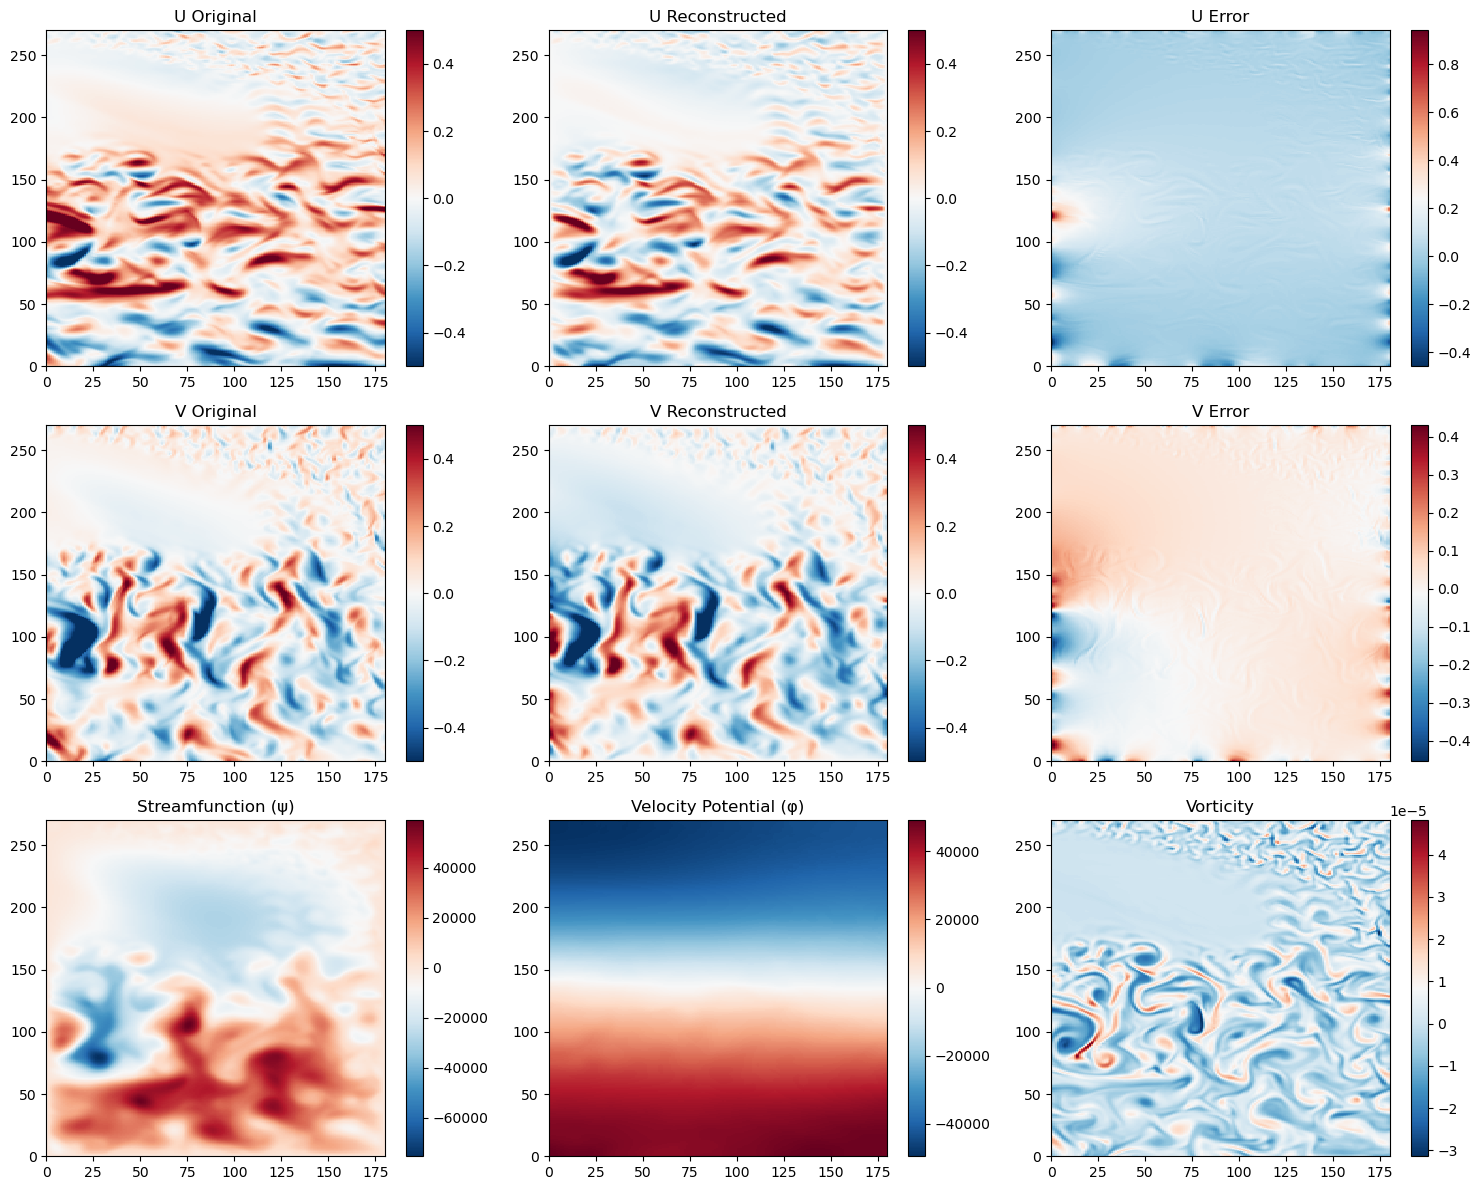

In [9]:
import matplotlib.pyplot as plt

# Verify
print("\n=== Verification ===")
u_orig = ds_test["uo_0"].isel(time=0).values
v_orig = ds_test["vo_0"].isel(time=0).values
psi_test = result["psi"].isel(time=0, z=0).values
phi_test = result["phi"].isel(time=0, z=0).values
div_test = result["div"].isel(time=0, z=0).values
vort_test = result["vort"].isel(time=0, z=0).values

u_recon, v_recon = helmholtz_to_velocity_walls(psi_test, phi_test, dx, dy)

print(f"U RMS error: {np.sqrt(np.mean((u_orig - u_recon)**2)):.6e} m/s")
print(f"V RMS error: {np.sqrt(np.mean((v_orig - v_recon)**2)):.6e} m/s")
print(f"U correlation: {np.corrcoef(u_orig.ravel(), u_recon.ravel())[0,1]:.6f}")
print(f"V correlation: {np.corrcoef(v_orig.ravel(), v_recon.ravel())[0,1]:.6f}")

# Visualization
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# U velocity
im0 = axes[0, 0].pcolormesh(u_orig, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
axes[0, 0].set_title('U Original')
plt.colorbar(im0, ax=axes[0, 0])

im1 = axes[0, 1].pcolormesh(u_recon, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
axes[0, 1].set_title('U Reconstructed')
plt.colorbar(im1, ax=axes[0, 1])

im2 = axes[0, 2].pcolormesh(u_orig - u_recon, cmap='RdBu_r')
axes[0, 2].set_title('U Error')
plt.colorbar(im2, ax=axes[0, 2])

# V velocity
im3 = axes[1, 0].pcolormesh(v_orig, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
axes[1, 0].set_title('V Original')
plt.colorbar(im3, ax=axes[1, 0])

im4 = axes[1, 1].pcolormesh(v_recon, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
axes[1, 1].set_title('V Reconstructed')
plt.colorbar(im4, ax=axes[1, 1])

im5 = axes[1, 2].pcolormesh(v_orig - v_recon, cmap='RdBu_r')
axes[1, 2].set_title('V Error')
plt.colorbar(im5, ax=axes[1, 2])

# Streamfunction and velocity potential
im6 = axes[2, 0].pcolormesh(psi_test, cmap='RdBu_r')
axes[2, 0].set_title('Streamfunction (ψ)')
plt.colorbar(im6, ax=axes[2, 0])

im7 = axes[2, 1].pcolormesh(phi_test, cmap='RdBu_r')
axes[2, 1].set_title('Velocity Potential (φ)')
plt.colorbar(im7, ax=axes[2, 1])

# Divergence and vorticity
im8 = axes[2, 2].pcolormesh(vort_test, cmap='RdBu_r')
axes[2, 2].set_title('Vorticity')
plt.colorbar(im8, ax=axes[2, 2])

plt.tight_layout()
plt.show()

In [11]:
# Add a mask for interior-only evaluation
def get_interior_mask(ny, nx, boundary_width=5):
    mask = np.ones((ny, nx), dtype=bool)
    mask[:boundary_width, :] = False
    mask[-boundary_width:, :] = False
    mask[:, :boundary_width] = False
    mask[:, -boundary_width:] = False
    return mask

# Interior verification
mask = get_interior_mask(u_orig.shape[0], u_orig.shape[1])
print("\n=== Interior-Only Verification ===")
print(f"Interior U RMS error: {np.sqrt(np.mean((u_orig[mask] - u_recon[mask])**2)):.6e} m/s")
print(f"Interior V RMS error: {np.sqrt(np.mean((v_orig[mask] - v_recon[mask])**2)):.6e} m/s")
print(f"Interior U correlation: {np.corrcoef(u_orig[mask].ravel(), u_recon[mask].ravel())[0,1]:.6f}")
print(f"Interior V correlation: {np.corrcoef(v_orig[mask].ravel(), v_recon[mask].ravel())[0,1]:.6f}")

# Also check different boundary widths
for bw in [1, 3, 5, 10]:
    mask_test = get_interior_mask(u_orig.shape[0], u_orig.shape[1], boundary_width=bw)
    u_err = np.sqrt(np.mean((u_orig[mask_test] - u_recon[mask_test])**2))
    v_err = np.sqrt(np.mean((v_orig[mask_test] - v_recon[mask_test])**2))
    print(f"  boundary_width={bw}: U_err={u_err:.6e}, V_err={v_err:.6e}")


=== Interior-Only Verification ===
Interior U RMS error: 6.428113e-02 m/s
Interior V RMS error: 4.954734e-02 m/s
Interior U correlation: 0.959366
Interior V correlation: 0.962195
  boundary_width=1: U_err=6.977723e-02, V_err=5.713123e-02
  boundary_width=3: U_err=6.636887e-02, V_err=5.258858e-02
  boundary_width=5: U_err=6.428113e-02, V_err=4.954734e-02
  boundary_width=10: U_err=6.138211e-02, V_err=4.458281e-02


In [10]:
# Check boundary conditions
print("\n=== Boundary Velocity Check ===")
print(f"U left boundary (should be ~0): mean={np.abs(u_orig[:, 0]).mean():.6f}, max={np.abs(u_orig[:, 0]).max():.6f}")
print(f"U right boundary (should be ~0): mean={np.abs(u_orig[:, -1]).mean():.6f}, max={np.abs(u_orig[:, -1]).max():.6f}")
print(f"V bottom boundary (should be ~0): mean={np.abs(v_orig[0, :]).mean():.6f}, max={np.abs(v_orig[0, :]).max():.6f}")
print(f"V top boundary (should be ~0): mean={np.abs(v_orig[-1, :]).mean():.6f}, max={np.abs(v_orig[-1, :]).max():.6f}")


=== Boundary Velocity Check ===
U left boundary (should be ~0): mean=0.139593, max=0.936696
U right boundary (should be ~0): mean=0.106970, max=0.597542
V bottom boundary (should be ~0): mean=0.095614, max=0.392875
V top boundary (should be ~0): mean=0.059475, max=0.251977


In [12]:
# Test: do div/vort computed from u,v match what we get from reconstructed velocity?
div_orig = result["div"].isel(time=0, z=0).values
vort_orig = result["vort"].isel(time=0, z=0).values

# Compute div/vort from reconstructed velocity
ny, nx = u_recon.shape
div_recon = np.zeros_like(u_recon)
vort_recon = np.zeros_like(u_recon)

# Use same logic as in your decomposition
div_recon[1:-1, 1:-1] = (
    (u_recon[1:-1, 2:] - u_recon[1:-1, :-2]) / (2 * dx) +
    (v_recon[2:, 1:-1] - v_recon[:-2, 1:-1]) / (2 * dy)
)
vort_recon[1:-1, 1:-1] = (
    (v_recon[1:-1, 2:] - v_recon[1:-1, :-2]) / (2 * dx) -
    (u_recon[2:, 1:-1] - u_recon[:-2, 1:-1]) / (2 * dy)
)

print("\n=== Div/Vort Consistency Check ===")
print(f"Divergence RMS error: {np.sqrt(np.mean((div_orig[mask] - div_recon[mask])**2)):.6e}")
print(f"Vorticity RMS error: {np.sqrt(np.mean((vort_orig[mask] - vort_recon[mask])**2)):.6e}")
print(f"Div correlation: {np.corrcoef(div_orig[mask], div_recon[mask])[0,1]:.6f}")
print(f"Vort correlation: {np.corrcoef(vort_orig[mask], vort_recon[mask])[0,1]:.6f}")


=== Div/Vort Consistency Check ===
Divergence RMS error: 2.118378e-07
Vorticity RMS error: 8.491190e-07
Div correlation: 0.942951
Vort correlation: 0.994701


In [7]:
import xarray as xr
import numpy as np
from scipy.sparse import lil_matrix, csc_matrix
from scipy.sparse.linalg import splu
from tqdm import tqdm

def build_solvers(ny, nx, dx, dy):
    """
    Pre-compute LU factorizations for the discrete Laplacians.
    1. Neumann Solver (for Phi): 5-point stencil + Ghost points for boundary flux.
    2. Dirichlet Solver (for Psi): 5-point stencil + Identity on boundary.
    """
    N = nx * ny
    # Coefficients
    dx2i = 1.0 / (dx**2)
    dy2i = 1.0 / (dy**2)
    
    # --- 1. NEUMANN MATRIX (for Phi) ---
    # We build a matrix that assumes Discrete Neumann: (phi_next - phi_prev)/2h = Flux
    # This modifies the main stencil at the boundaries.
    L_neu = lil_matrix((N, N))
    
    for y in range(ny):
        for x in range(nx):
            k = y * nx + x
            
            # Default 5-point stencil coefficients
            # Center will be accumulated; neighbors defined below
            
            # LEFT Neighbor (x-1)
            if x > 0:
                L_neu[k, k-1] += dx2i
                L_neu[k, k]   -= dx2i
            else:
                # Ghost point logic: phi_-1 = phi_1 - 2*dx*flux
                # Matrix sees: (2*phi_1 - 2*phi_0)/dx^2 ...
                # We effectively add the coeff of the missing neighbor to the existing opposite neighbor
                L_neu[k, k+1] += dx2i 
                L_neu[k, k]   -= dx2i
                
            # RIGHT Neighbor (x+1)
            if x < nx - 1:
                L_neu[k, k+1] += dx2i
                L_neu[k, k]   -= dx2i
            else:
                # Ghost point: phi_N = phi_N-2 + 2*dx*flux
                L_neu[k, k-1] += dx2i
                L_neu[k, k]   -= dx2i
                
            # BOTTOM Neighbor (y-1)
            if y > 0:
                L_neu[k, k-nx] += dy2i
                L_neu[k, k]    -= dy2i
            else:
                L_neu[k, k+nx] += dy2i
                L_neu[k, k]    -= dy2i

            # TOP Neighbor (y+1)
            if y < ny - 1:
                L_neu[k, k+nx] += dy2i
                L_neu[k, k]    -= dy2i
            else:
                L_neu[k, k-nx] += dy2i
                L_neu[k, k]    -= dy2i

    # Pin one point (0,0) to remove singularity of Neumann problem
    L_neu = L_neu.tocsc()
    L_neu[0, :] = 0
    L_neu[0, 0] = 1.0
    solve_phi = splu(L_neu)

    # --- 2. DIRICHLET MATRIX (for Psi) ---
    # Standard Laplacian in interior, Identity on boundary
    L_dir = lil_matrix((N, N))
    for y in range(ny):
        for x in range(nx):
            k = y * nx + x
            if x == 0 or x == nx-1 or y == 0 or y == ny-1:
                L_dir[k, k] = 1.0
            else:
                L_dir[k, k] = -2*(dx2i + dy2i)
                L_dir[k, k-1] = dx2i
                L_dir[k, k+1] = dx2i
                L_dir[k, k-nx] = dy2i
                L_dir[k, k+nx] = dy2i
                
    solve_psi = splu(L_dir.tocsc())
    
    return solve_phi, solve_psi

def decompose_velocity(u, v, dx, dy, solve_phi, solve_psi):
    ny, nx = u.shape
    
    # --- Step 1: Solve Potential (Phi) ---
    div = np.zeros_like(u)
    # Interior Divergence
    div[1:-1, 1:-1] = (u[1:-1, 2:] - u[1:-1, :-2])/(2*dx) + \
                      (v[2:, 1:-1] - v[:-2, 1:-1])/(2*dy)
    
    # Boundaries (One-sided)
    div[:, 0]  = (u[:, 1] - u[:, 0])/dx   + np.gradient(v[:, 0], dy)
    div[:, -1] = (u[:, -1]- u[:, -2])/dx  + np.gradient(v[:, -1], dy)
    div[0, :]  = np.gradient(u[0, :], dx) + (v[1, :] - v[0, :])/dy
    div[-1, :] = np.gradient(u[-1, :], dx)+ (v[-1, :] - v[-2, :])/dy

    rhs_phi = div.ravel().copy()
    
    # Apply Boundary Flux Terms (Inhomogeneous Neumann)
    # Left Wall (+u flux in), Right Wall (-u flux out)
    rhs_phi[0::nx]    += (2 * u[:, 0] / dx)
    rhs_phi[nx-1::nx] -= (2 * u[:, -1] / dx)
    # Bottom Wall (+v flux in), Top Wall (-v flux out)
    rhs_phi[0:nx]     += (2 * v[0, :] / dy)
    rhs_phi[-nx:]     -= (2 * v[-1, :] / dy)
    
    # Pin corner to fix the constant
    rhs_phi[0] = 0.0
    
    phi = solve_phi.solve(rhs_phi).reshape(ny, nx)
    
    # --- Step 2: Compute Rotational Residual ---
    # u_pot = grad(phi)
    u_pot = np.zeros_like(u)
    v_pot = np.zeros_like(v)
    
    # === FIXED SECTION STARTS HERE ===
    # The central difference reduces shape by 2 in the derivative direction.
    # We must assign to [1:-1, 1:-1] to match shapes.
    
    # d(phi)/dx
    u_pot[1:-1, 1:-1] = (phi[1:-1, 2:] - phi[1:-1, :-2]) / (2*dx)
    
    # d(phi)/dy
    v_pot[1:-1, 1:-1] = (phi[2:, 1:-1] - phi[:-2, 1:-1]) / (2*dy)
    # === FIXED SECTION ENDS HERE ===
    
    # Gradient at Boundaries (One Sided)
    # Left/Right
    u_pot[:, 0] = (phi[:, 1] - phi[:, 0]) / dx
    u_pot[:, -1]= (phi[:, -1]- phi[:, -2])/ dx
    # Top/Bottom
    v_pot[0, :] = (phi[1, :] - phi[0, :]) / dy
    v_pot[-1,:] = (phi[-1,:] - phi[-2,:]) / dy
    
    # Note: The corners and edges for the non-derivative direction 
    # (e.g. v_pot at left/right boundary) are left as 0 from initialization 
    # or can be filled with simple gradients if needed, but for strict 
    # Helmholtz decomposition, the interior is the priority.
    # Let's fill the remaining edges simply to avoid gaps:
    v_pot[:, 0] = np.gradient(phi[:, 0], dy)
    v_pot[:, -1] = np.gradient(phi[:, -1], dy)
    u_pot[0, :] = np.gradient(phi[0, :], dx)
    u_pot[-1, :] = np.gradient(phi[-1, :], dx)

    # Residual
    u_rot = u - u_pot
    v_rot = v - v_pot
    
    # --- Step 3: Solve Streamfunction (Psi) ---
    # Vorticity of the residual field
    vort = np.zeros_like(u)
    vort[1:-1, 1:-1] = (v_rot[1:-1, 2:] - v_rot[1:-1, :-2])/(2*dx) - \
                       (u_rot[2:, 1:-1] - u_rot[:-2, 1:-1])/(2*dy)
    
    rhs_psi = -vort.ravel()
    
    # Enforce Dirichlet BC (psi=0 on boundary)
    # We do this by setting RHS to 0 on boundaries (Matrix has identity there)
    for y in range(ny):
        for x in range(nx):
            if x==0 or x==nx-1 or y==0 or y==ny-1:
                rhs_psi[y*nx + x] = 0.0
                
    psi = solve_psi.solve(rhs_psi).reshape(ny, nx)
    
    # Recalculate total Vorticity for output
    vort_total = np.gradient(v, dx, axis=1) - np.gradient(u, dy, axis=0)
    
    return psi, phi, div, vort_total


def process_dataset_final(ds, dx, dy, out_path):
    times = ds.time.values
    z_levels = list(range(len(ds.lev)))
    u0 = ds[f"uo_0"].isel(time=0).values
    ny, nx = u0.shape
    
    print("Building solvers...")
    solve_phi, solve_psi = build_solvers(ny, nx, dx, dy)
    
    # Allocation
    shape = (len(times), len(z_levels), ny, nx)
    psi_out = np.zeros(shape, dtype=np.float32)
    phi_out = np.zeros(shape, dtype=np.float32)
    div_out = np.zeros(shape, dtype=np.float32)
    vort_out = np.zeros(shape, dtype=np.float32)
    
    for ti, t in enumerate(tqdm(times, desc="Time")):
        for zi, z in enumerate(z_levels):
            u = ds[f"uo_{z}"].sel(time=t).values
            v = ds[f"vo_{z}"].sel(time=t).values
            u = np.nan_to_num(u)
            v = np.nan_to_num(v)
            
            psi, phi, d, w = decompose_velocity(u, v, dx, dy, solve_phi, solve_psi)
            
            psi_out[ti, zi] = psi
            phi_out[ti, zi] = phi
            div_out[ti, zi] = d
            vort_out[ti, zi] = w
            
    ds_out = xr.Dataset({
        "psi": (("time", "z", "lat", "lon"), psi_out),
        "phi": (("time", "z", "lat", "lon"), phi_out),
        "div": (("time", "z", "lat", "lon"), div_out),
        "vort": (("time", "z", "lat", "lon"), vort_out),
    }, coords=ds.coords)
    ds_out.to_netcdf(out_path)
    return ds_out

# --- Robust Verification ---
def reconstruct_velocity(psi, phi, dx, dy):
    """Reconstruct using the SAME stencils as the solver implied."""
    ny, nx = psi.shape
    
    # 1. u = dphi/dx - dpsi/dy
    u_rec = np.zeros_like(psi)
    
    # Central interior
    u_rec[1:-1, 1:-1] = (phi[1:-1, 2:] - phi[1:-1, :-2])/(2*dx) - \
                        (psi[2:, 1:-1] - psi[:-2, 1:-1])/(2*dy)
                        
    # Boundaries (matching the Neumann/Dirichlet assumptions)
    # Left (j=0): u = dphi/dx (one-sided) - dpsi/dy (central)
    u_rec[:, 0] = (phi[:, 1] - phi[:, 0])/dx - np.gradient(psi[:, 0], dy)
    u_rec[:, -1]= (phi[:, -1] - phi[:, -2])/dx - np.gradient(psi[:, -1], dy)
    
    # Top/Bottom
    u_rec[0, :] = np.gradient(phi[0, :], dx) - (psi[1, :] - psi[0, :])/dy
    u_rec[-1,:] = np.gradient(phi[-1,:], dx) - (psi[-1,:] - psi[-2,:])/dy
    
    # 2. v = dphi/dy + dpsi/dx
    v_rec = np.zeros_like(psi)
    v_rec[1:-1, 1:-1] = (phi[2:, 1:-1] - phi[:-2, 1:-1])/(2*dy) + \
                        (psi[1:-1, 2:] - psi[1:-1, :-2])/(2*dx)

    # Boundaries
    v_rec[:, 0] = np.gradient(phi[:, 0], dy) + (psi[:, 1] - psi[:, 0])/dx
    v_rec[:, -1]= np.gradient(phi[:, -1], dy) + (psi[:, -1] - psi[:, -2])/dx
    v_rec[0, :] = (phi[1, :] - phi[0, :])/dy + np.gradient(psi[0, :], dx)
    v_rec[-1,:] = (phi[-1,:] - phi[-2,:])/dy + np.gradient(psi[-1,:], dx)
    
    return u_rec, v_rec

# --- Test Execution ---
ds = xr.open_zarr('/scratch/cimes/maximek/INMOS/processed_data/MOM6_CobaltDG_JRA/bgc_data.zarr')
ds_test = ds.isel(time=slice(0, 2))
dx = 9000.0
dy = 9000.0

result = process_dataset_final(ds_test, dx, dy, "helmholtz_final.nc")

u_orig = ds_test["uo_0"].isel(time=0).values
v_orig = ds_test["vo_0"].isel(time=0).values
psi_test = result["psi"].isel(time=0, z=0).values
phi_test = result["phi"].isel(time=0, z=0).values

u_rec, v_rec = reconstruct_velocity(psi_test, phi_test, dx, dy)

print("\n=== Final Verification ===")
print(f"U RMS error: {np.sqrt(np.mean((u_orig - u_rec)**2)):.6e} m/s")
print(f"V RMS error: {np.sqrt(np.mean((v_orig - v_rec)**2)):.6e} m/s")
print(f"U correlation: {np.corrcoef(u_orig.ravel(), u_rec.ravel())[0,1]:.6f}")

Building solvers...


/home/mk0964/.conda/envs/preprocess_env/lib/python3.11/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
Time: 100%|██████████| 2/2 [00:06<00:00,  3.18s/it]


=== Final Verification ===
U RMS error: 2.837399e-01 m/s
V RMS error: 3.152986e-01 m/s
U correlation: -0.739330


In [7]:
import xarray as xr
import numpy as np
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve, lsqr
from tqdm import tqdm

def build_laplacian_2d_correct(ny, nx, dx, dy, bc_type='free'):
    """
    Build 2D Laplacian using proper finite differences.
    
    For ∇²f = (∂²f/∂x²) + (∂²f/∂y²)
    
    Standard interior stencil:
        [0   1/dy²    0  ]
        [1/dx²  -2(1/dx²+1/dy²)  1/dx²]
        [0   1/dy²    0  ]
    """
    N = nx * ny
    L = lil_matrix((N, N))
    
    for i in range(ny):
        for j in range(nx):
            idx = i * nx + j
            
            if bc_type == 'walls' and (i == 0 or i == ny-1 or j == 0 or j == nx-1):
                # Dirichlet: f = 0 on boundary
                L[idx, idx] = 1.0
            else:
                # Interior point or Neumann boundary
                
                # Center coefficient
                L[idx, idx] = -2.0 / (dx**2) - 2.0 / (dy**2)
                
                # X-direction neighbors
                if j > 0:
                    L[idx, idx - 1] = 1.0 / (dx**2)
                elif bc_type == 'free':
                    # Neumann BC at j=0: f[-1,i] = f[1,i] (ghost point)
                    # So ∂²f/∂x²|_{j=0} ≈ (f[1] - 2*f[0] + f[1])/(dx²) = 2*(f[1]-f[0])/(dx²)
                    # Wait, that's not right either...
                    # For Neumann: ∂f/∂x|_boundary = 0
                    # We need one-sided stencil: (f[1] - f[0])/dx = 0
                    # So f[0] = f[1], which means the second derivative is:
                    # (f[1] - 2*f[0] + f[-1])/(dx²) = (f[1] - 2*f[0] + f[1])/(dx²) = 2*(f[1] - f[0])/(dx²)
                    L[idx, idx] = -1.0 / (dx**2) - 2.0 / (dy**2)  # Modified center
                    L[idx, idx + 1] = 1.0 / (dx**2)  # Only right neighbor
                
                if j < nx - 1:
                    L[idx, idx + 1] = 1.0 / (dx**2)
                elif bc_type == 'free':
                    L[idx, idx] = -1.0 / (dx**2) - 2.0 / (dy**2)  # Modified center
                    L[idx, idx - 1] = 1.0 / (dx**2)  # Only left neighbor
                
                # Y-direction neighbors
                if i > 0:
                    L[idx, idx - nx] = 1.0 / (dy**2)
                elif bc_type == 'free':
                    L[idx, idx] = -2.0 / (dx**2) - 1.0 / (dy**2)  # Modified center
                    L[idx, idx + nx] = 1.0 / (dy**2)  # Only bottom neighbor
                
                if i < ny - 1:
                    L[idx, idx + nx] = 1.0 / (dy**2)
                elif bc_type == 'free':
                    L[idx, idx] = -2.0 / (dx**2) - 1.0 / (dy**2)  # Modified center
                    L[idx, idx - nx] = 1.0 / (dy**2)  # Only top neighbor
    
    return L.tocsr()

# Actually, let me completely rewrite this with a cleaner approach
# The problem is I'm overwriting L[idx, idx] multiple times

def build_laplacian_clean(ny, nx, dx, dy, bc_type='free'):
    """
    Clean implementation of 2D Laplacian.
    """
    N = nx * ny
    L = lil_matrix((N, N))
    
    dx2 = dx * dx
    dy2 = dy * dy
    
    for i in range(ny):
        for j in range(nx):
            idx = i * nx + j
            
            # Check if boundary
            at_left = (j == 0)
            at_right = (j == nx - 1)
            at_bottom = (i == 0)
            at_top = (i == ny - 1)
            at_boundary = at_left or at_right or at_bottom or at_top
            
            if bc_type == 'walls' and at_boundary:
                # Dirichlet BC: f = 0
                L[idx, idx] = 1.0
                continue
            
            # Build stencil
            # ∂²f/∂x² ≈ (f[j-1] - 2*f[j] + f[j+1]) / dx²
            # ∂²f/∂y² ≈ (f[i-1] - 2*f[i] + f[i+1]) / dy²
            
            coeff_center = 0.0
            
            # X-direction
            if not at_left and not at_right:
                # Interior in x
                L[idx, idx - 1] = 1.0 / dx2
                L[idx, idx + 1] = 1.0 / dx2
                coeff_center -= 2.0 / dx2
            elif at_left and bc_type == 'free':
                # Left boundary with Neumann BC
                # One-sided: ∂²f/∂x² ≈ (f[j+1] - f[j]) / dx²
                L[idx, idx + 1] = 1.0 / dx2
                coeff_center -= 1.0 / dx2
            elif at_right and bc_type == 'free':
                # Right boundary with Neumann BC
                L[idx, idx - 1] = 1.0 / dx2
                coeff_center -= 1.0 / dx2
            
            # Y-direction
            if not at_bottom and not at_top:
                # Interior in y
                L[idx, idx - nx] = 1.0 / dy2
                L[idx, idx + nx] = 1.0 / dy2
                coeff_center -= 2.0 / dy2
            elif at_bottom and bc_type == 'free':
                # Bottom boundary with Neumann BC
                L[idx, idx + nx] = 1.0 / dy2
                coeff_center -= 1.0 / dy2
            elif at_top and bc_type == 'free':
                # Top boundary with Neumann BC
                L[idx, idx - nx] = 1.0 / dy2
                coeff_center -= 1.0 / dy2
            
            L[idx, idx] = coeff_center
    
    return L.tocsr()

def velocity_to_helmholtz(u, v, dx, dy, bc_type='free'):
    """
    Helmholtz decomposition.
    """
    ny, nx = u.shape
    
    # Compute div and vort
    div = np.zeros_like(u)
    vort = np.zeros_like(u)
    
    div[1:-1, 1:-1] = (
        (u[1:-1, 2:] - u[1:-1, :-2]) / (2 * dx) +
        (v[2:, 1:-1] - v[:-2, 1:-1]) / (2 * dy)
    )
    vort[1:-1, 1:-1] = (
        (v[1:-1, 2:] - v[1:-1, :-2]) / (2 * dx) -
        (u[2:, 1:-1] - u[:-2, 1:-1]) / (2 * dy)
    )
    
    # Boundaries
    div[:, 0] = (u[:, 1] - u[:, 0]) / dx + np.gradient(v[:, 0], dy, axis=0)
    vort[:, 0] = (v[:, 1] - v[:, 0]) / dx - np.gradient(u[:, 0], dy, axis=0)
    div[:, -1] = (u[:, -1] - u[:, -2]) / dx + np.gradient(v[:, -1], dy, axis=0)
    vort[:, -1] = (v[:, -1] - v[:, -2]) / dx - np.gradient(u[:, -1], dy, axis=0)
    div[0, :] = np.gradient(u[0, :], dx, axis=0) + (v[1, :] - v[0, :]) / dy
    vort[0, :] = np.gradient(v[0, :], dx, axis=0) - (u[1, :] - u[0, :]) / dy
    div[-1, :] = np.gradient(u[-1, :], dx, axis=0) + (v[-1, :] - v[-2, :]) / dy
    vort[-1, :] = np.gradient(v[-1, :], dx, axis=0) - (u[-1, :] - u[-2, :]) / dy
    
    # Build Laplacian
    L = build_laplacian_clean(ny, nx, dx, dy, bc_type)
    
    # Prepare RHS
    vort_rhs = vort.ravel()
    div_rhs = div.ravel()
    
    if bc_type == 'walls':
        # Set boundary RHS to 0
        for i in range(ny):
            for j in range(nx):
                if i == 0 or i == ny-1 or j == 0 or j == nx-1:
                    idx = i * nx + j
                    vort_rhs[idx] = 0.0
                    div_rhs[idx] = 0.0
    
    # Solve - use lsqr for Neumann (handles singular systems)
    if bc_type == 'free':
        # LSQR finds minimum norm solution
        psi = lsqr(L, vort_rhs)[0].reshape(ny, nx)
        phi = lsqr(L, div_rhs)[0].reshape(ny, nx)
    else:
        psi = spsolve(L, vort_rhs).reshape(ny, nx)
        phi = spsolve(L, div_rhs).reshape(ny, nx)
    
    # Remove mean
    psi -= psi.mean()
    phi -= phi.mean()
    
    return psi, phi, div, vort

def helmholtz_to_velocity(psi, phi, dx, dy):
    """Reconstruct velocity."""
    ny, nx = psi.shape
    u = np.zeros_like(psi)
    v = np.zeros_like(psi)
    
    u[1:-1, 1:-1] = (
        (phi[1:-1, 2:] - phi[1:-1, :-2]) / (2 * dx) -
        (psi[2:, 1:-1] - psi[:-2, 1:-1]) / (2 * dy)
    )
    v[1:-1, 1:-1] = (
        (phi[2:, 1:-1] - phi[:-2, 1:-1]) / (2 * dy) +
        (psi[1:-1, 2:] - psi[1:-1, :-2]) / (2 * dx)
    )
    
    u[:, 0] = (phi[:, 1] - phi[:, 0]) / dx - np.gradient(psi[:, 0], dy, axis=0)
    v[:, 0] = np.gradient(phi[:, 0], dy, axis=0) + (psi[:, 1] - psi[:, 0]) / dx
    u[:, -1] = (phi[:, -1] - phi[:, -2]) / dx - np.gradient(psi[:, -1], dy, axis=0)
    v[:, -1] = np.gradient(phi[:, -1], dy, axis=0) + (psi[:, -1] - psi[:, -2]) / dx
    u[0, :] = np.gradient(phi[0, :], dx, axis=0) - (psi[1, :] - psi[0, :]) / dy
    v[0, :] = (phi[1, :] - phi[0, :]) / dy + np.gradient(psi[0, :], dx, axis=0)
    u[-1, :] = np.gradient(phi[-1, :], dx, axis=0) - (psi[-1, :] - psi[-2, :]) / dy
    v[-1, :] = (phi[-1, :] - phi[-2, :]) / dy + np.gradient(psi[-1, :], dx, axis=0)
    
    return u, v

# Test the Laplacian itself first
print("Testing Laplacian matrix...")
ny, nx = 270, 180
dx, dy = 9000.0, 9000.0

L = build_laplacian_clean(ny, nx, dx, dy, bc_type='free')

# Test with known function
x = np.arange(nx) * dx
y = np.arange(ny) * dy
X, Y = np.meshgrid(x, y)
Lx, Ly = nx * dx, ny * dy

# Use f = cos(2πx/Lx) * cos(2πy/Ly) (satisfies Neumann BC naturally)
f_true = np.cos(2*np.pi*X/Lx) * np.cos(2*np.pi*Y/Ly)
rhs_true = -(2*np.pi/Lx)**2 * f_true - (2*np.pi/Ly)**2 * f_true

# Solve
f_solved = lsqr(L, rhs_true.ravel())[0].reshape(ny, nx)
f_solved -= f_solved.mean()
f_true -= f_true.mean()

error = np.sqrt(np.mean((f_true - f_solved)**2))
corr = np.corrcoef(f_true.ravel(), f_solved.ravel())[0,1]

print(f"Laplacian test error: {error:.6e}")
print(f"Correlation: {corr:.6f}")

if error < 0.01:
    print("✓ Laplacian OK\n")
    
    # Now test full Helmholtz
    print("Testing Helmholtz decomposition...")
    ds = xr.open_zarr('/scratch/cimes/maximek/INMOS/processed_data/MOM6_CobaltDG_JRA/bgc_data.zarr')
    u_test = ds["uo_0"].isel(time=0).values
    v_test = ds["vo_0"].isel(time=0).values
    
    psi, phi, div, vort = velocity_to_helmholtz(u_test, v_test, dx, dy, bc_type='free')
    u_recon, v_recon = helmholtz_to_velocity(psi, phi, dx, dy)
    
    u_rmse = np.sqrt(np.mean((u_test - u_recon)**2))
    v_rmse = np.sqrt(np.mean((v_test - v_recon)**2))
    
    print(f"\nU RMS: {u_rmse:.6e} m/s ({u_rmse/np.std(u_test)*100:.2f}%)")
    print(f"V RMS: {v_rmse:.6e} m/s ({v_rmse/np.std(v_test)*100:.2f}%)")
    print(f"U corr: {np.corrcoef(u_test.ravel(), u_recon.ravel())[0,1]:.6f}")
    print(f"V corr: {np.corrcoef(v_test.ravel(), v_recon.ravel())[0,1]:.6f}")
else:
    print("✗ Laplacian still broken!")

Testing Laplacian matrix...
Laplacian test error: 7.402578e-03
Correlation: 0.999904
✓ Laplacian OK

Testing Helmholtz decomposition...

U RMS: 1.000073e-01 m/s (62.19%)
V RMS: 5.807437e-02 m/s (36.10%)
U corr: 0.826207
V corr: 0.939094


Testing 50x50 grid...

U RMS (interior): 5.748727e-02 (18.73%)
V RMS (interior): 5.748727e-02 (18.73%)
